**Libraries**

In [16]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [13]:
data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [20]:
svm_clf = SVC(kernel="linear")
svm_clf.fit(x_train_scaled, y_train)

svm_pred = svm_clf.predict(x_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
print(svm_acc)
print(classification_report(y_test, svm_pred))

0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.80      0.89      0.84         9
           2       0.90      0.82      0.86        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



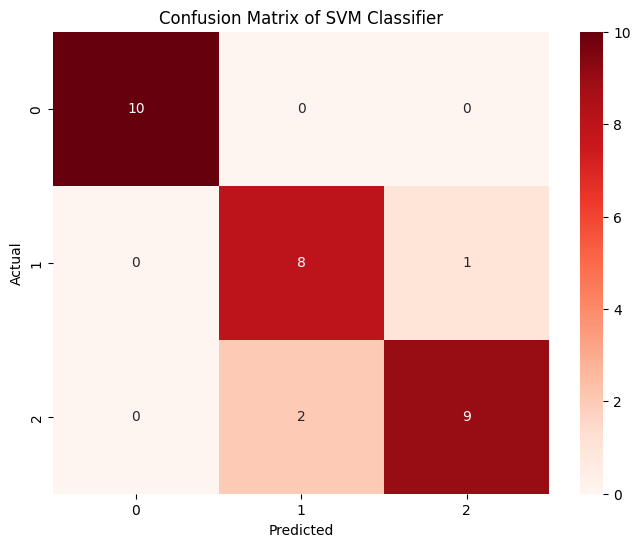

In [22]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, cmap="Reds")
plt.title("Confusion Matrix of SVM Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(x_train_scaled, y_train)

knn_pred = knn_clf.predict(x_test_scaled)

In [29]:
print(accuracy_score(y_test, knn_pred))

0.9666666666666667


In [30]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



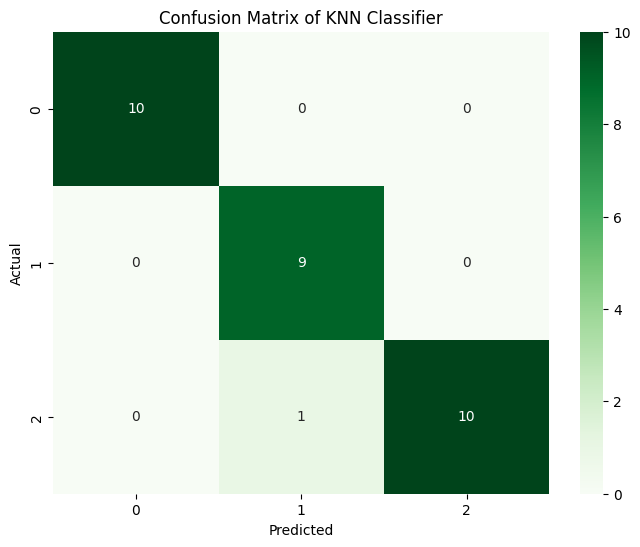

In [31]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, cmap="Greens")
plt.title("Confusion Matrix of KNN Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()